In [94]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [95]:
# Calculate Forward Price
def forward_price (S0, r, y, T):
    "Theoretical forward price under continuous compounding:"
    "F = S0 * exp(r*T)"
    return S0 * np.exp((r-y) * T)

# Detect Arbitrage
def detect_arbitrage (S0,r,q,T,F_market):
    F_theoretical = forward_price(S0,r,q,T)

    if F_market > F_theoretical:
        return "Cash-and-carry arbitrage (Forward overpriced)"
    elif F_market < F_theoretical:
        return "Reverse Cash-and-carry (Forward underpriced)"
    else:
        return "No arbitrage"

# Arbitrage Profit
def arbitrage_profit (S0, r, T, q, F_market, tol=1e-6):
    F_theoretical = forward_price(S0,r,q,T)
    diff= F_market - F_theoretical

    if abs (diff) <= tol:
        return 0.0, "No arbitrage (Within tolerance)"
    elif diff > tol:
        return diff, "Cash-and-carry (Forward overpriced)"
    else:
        return -diff, "Reverse cash-and-carry (Forward undepriced)"


# Forward price functions
def run_single_case(S0, r, y, T, F_market): #Single case function, define (S0,r,T,q,F_market)
    F_theoretical = forward_price(S0,r,y,T)
    print("Theoritical Fair forward price :", F_theoretical)
    print(detect_arbitrage(S0,r,T,y,F_market))
    profit,label = arbitrage_profit(S0, r, T, y, F_market)
    print (f"Arbitrage profit at maturity (per unit):",profit)
    S_T = np.linspace (50,100,150) # Range of possible future spot prices
    payoff = S_T - F_theoretical

    plt.figure()
    plt.plot(S_T, payoff)
    plt.axhline(0)
    plt.axvline(F_theoretical)
    plt.title("Long Forward Payoff at Maturity")
    plt.xlabel("Spot price at maturity (S_T)")
    plt.ylabel("Payoff (S_T - F_theoretical)")
    plt.show()
    
def run_multiple_cases(cases):
    
    df= pd.DataFrame(cases)
    df["F_theory"] = forward_price(df["S0"],df["r"],df["y"],df["T"])
    df["mispricing"]= df["F_market"] - df["F_theory"]
    
    print("")
    print("Multiple Cases Summary Table")
    print(df)

    

# Compare simulated mean vs theoritical expectation
def comparison_gbm(S0, r, y, sigma, T, N): 
    Z = np.random.normal(0, 1, N)
    ST = gbm_simulation(S0, r, y, sigma, T, Z)
    simulated_mean = np.mean(ST)
    theoretical_mean = forward_price(S0, r, y, T)

    print("")
    print(f"Simulated E[ST]   : {simulated_mean:.6f}")
    print(f"Theoretical E[ST] : {theoretical_mean:.6f}")
    print(f"Difference        : {simulated_mean - theoretical_mean:.6f}")

    #Plotting Histogram
    plt.figure(figsize=(10,6))
    plt.hist(ST, bins=120, alpha=0.6, color="skyblue", edgecolor="black")
    plt.axvline(theoretical_mean, color="red", linewidth=3, label="Theoretical E[ST]")
    plt.title("GBM Terminal Price Distribution")
    plt.xlabel("Terminal Price (S_T)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Running gbm terminal price formula
def gbm_simulation(S0, r, y, sigma, T, Z):
    #Simulate standard normal random variables
    return S0 * np.exp((r - y - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Antithetic Variates
def antithetic_variates_call (S0, K, r, y, sigma, T):
    payoffs =[]
    for i in range(N//2):
        Z = np.random.normal(0,1)
        ST1 = S0 * np.exp((r-y-0.5*sigma**2) * T + sigma * np.sqrt(T) * Z)
        ST2 = S0 * np.exp((r-y-0.5*sigma**2) * T - sigma * np.sqrt(T) * Z)
        payoff1 = max(ST1-K,0)
        payoff2 = max(ST2-K,0)
        pair_payoff = (payoff1+payoff2) * 0.5
        payoffs.append(pair_payoff)
    price, antithetic_variates, ci_low, ci_high =mc_summary(payoffs, r, T)
    return antithetic_variates

def antithetic_variates_put (S0, K, r, y, sigma, T):
    payoffs =[]
    for i in range(N//2):
        Z = np.random.normal(0,1)
        ST1 = S0 * np.exp((r-y-0.5*sigma**2) * T + sigma * np.sqrt(T) * Z)
        ST2 = S0 * np.exp((r-y-0.5*sigma**2) * T - sigma * np.sqrt(T) * Z)
        payoff1 = max(K-ST1,0)
        payoff2 = max(K-ST2,0)
        pair_payoff = (payoff1+payoff2) * 0.5
        payoffs.append(pair_payoff)
    price, antithetic_variates, ci_low, ci_high = mc_summary(payoffs, r, T)
    return antithetic_variates
    
#Price, std_error, CI_low, CI_high Summary Function
def mc_summary(payoffs, r, T):
    payoffs = np.array(payoffs, dtype=float)
    discounted_payoffs = np.exp(-r * T) * payoffs

    price = np.mean(discounted_payoffs)
    std_error = np.std(discounted_payoffs, ddof=1) / np.sqrt(len(discounted_payoffs))
    ci_low = price - 1.96 * std_error
    ci_high = price + 1.96 * std_error
    return price, std_error, ci_low, ci_high

# Black-Scholes Option Price Function
def black_scholes_option_price (S0, K, r, y, sigma, T, greeks):

    d1 = (np.log(S0/K) + (r - y + 0.5*sigma**2)*T / (sigma*np.sqrt(T)))
    d2 = d1 - sigma*np.sqrt(T)

    bs_call_price = (S0*np.exp(-y*T) * norm.cdf(d1)) - (K * np.exp(-r*T) * norm.cdf(d2))
    bs_put_price = (K * np.exp(-r*T) * norm.cdf(-d2)) - (S0*np.exp(-y*T) * norm.cdf(-d1))
    print("\nBlack-Scholes Option Pricing")
    print(f"Call Price  : {bs_call_price:.4f}")
    print(f"Put Price   : {bs_put_price:.4f}")
    print(f"Delta Call  : {greeks["delta_call"]:.4f}")
    print(f"Delta Put   : {greeks["delta_put"]:.4f}")
    print(f"Gamma       : {greeks["gamma"]:.4f}")
    print(f"Vega        : {greeks["vega"]:.4f}")
    print(f"Theta Call  : {greeks["theta_call"]:.4f}")
    print(f"Theta Put   : {greeks["theta_put"]:.4f}")
    put_call_parity_test(bs_call_price, bs_put_price, S0, K, r, y, T)

def black_scholes_greeks(S0, K, r, y, sigma, T):
    d1 = (np.log(S0 / K) + (r - y + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    pdf_d1 = norm.pdf(d1)

    delta_call = np.exp(-y*T) * norm.cdf(d1)
    delta_put = -np.exp(-y*T) * norm.cdf(-d1)

    gamma = np.exp(-y*T) * pdf_d1 / (S0 * sigma * np.sqrt(T))

    vega = S0 * np.exp(-y*T) * pdf_d1 * np.sqrt(T)

    theta_call = (
        -S0 * pdf_d1 * sigma * np.exp(-y*T) / (2*np.sqrt(T))
        - r * K * np.exp(-r*T) * norm.cdf(d2)
        + y * S0 * np.exp(-y*T) * norm.cdf(d1)
    )

    theta_put = (
        -S0 * pdf_d1 * sigma * np.exp(-y*T) / (2*np.sqrt(T))
        + r * K * np.exp(-r*T) * norm.cdf(-d2)
        - y * S0 * np.exp(-y*T) * norm.cdf(-d1)
    )
    return {
        "delta_call": delta_call,
        "delta_put": delta_put,
        "gamma": gamma,
        "vega": vega,
        "theta_call": theta_call,
        "theta_put": theta_put
    }


# European Option Call-Put Price Function
def european_option_price (S0, r, y, T, sigma, N, total_payoff_call, total_payoff_put, K):
    payoffs_euro_call = []
    payoffs_euro_put = []

    for i in range(N):
        Z = np.random.normal(0, 1)
        ST = gbm_simulation(S0, r, y, sigma, T, Z)
        payoff_call = max (ST - K, 0)
        payoffs_euro_call.append(payoff_call)
        payoff_put = max (K - ST,0) 
        payoffs_euro_put.append(payoff_put)
    call_option_price,std_error_call , call_ci_low, call_ci_high = mc_summary(payoffs_euro_call, r, T) 
    put_option_price,std_error_put , put_ci_low, put_ci_high = mc_summary(payoffs_euro_put, r, T)
    antithetic_var_call = antithetic_variates_call (S0, K, r, y, sigma, T)
    antithetic_var_put = antithetic_variates_put (S0, K, r, y, sigma, T)
    print ("\nMonte Carlo (European) Option Pricing")
    print ( "Simulations                    :",N)
    print("")
    print (f"Call price                     : {call_option_price:.4f}")
    print (f"Std Error                      : {std_error_call:.4f}")
    print (f"Antithetic Variates            : {antithetic_var_call:.4f}")
    print (f"95% CI                         :[{call_ci_low:.4f},{call_ci_high:.4f}]")
    print("")
    print (f"Put price                      : {put_option_price:.4f}")
    print (f"Std Error (Standard MC)        : {std_error_put:.4f}")
    print (f"Std Error (Antithetic MC)      : {antithetic_var_put:.4f}")
    print (f"95% CI                         :[{put_ci_low:.4f},{put_ci_high:.4f}]")
    put_call_parity_test(call_option_price, put_option_price, S0, K, r, y, T)

# Asian Option Call-Put Price Function
def asian_option_price (S0, r, y, T, sigma, N, M, total_payoff_call, total_payoff_put, ST_sum, K):
    dt = T / M
    payoffs_asia_call = []
    payoffs_asia_put = []
    
    for i in range(N):
        ST = S0
        ST_sum = 0
        
        for j in range (M):
            Z = np.random.normal(0, 1)
            ST = gbm_simulation(ST, r, y, sigma, dt, Z)
            ST_sum += ST
            ST_mean = ST_sum / M
        
        payoff_call = max(ST_mean - K, 0)
        payoffs_asia_call.append(payoff_call)
        payoff_put = max(K - ST_mean, 0)
        payoffs_asia_put.append(payoff_put)
    
    call_option_price,std_error_call , call_ci_low, call_ci_high = mc_summary(payoffs_asia_call, r, T) 
    put_option_price,std_error_put , put_ci_low, put_ci_high = mc_summary(payoffs_asia_put, r, T)
    antithetic_var_call = antithetic_variates_call (S0, K, r, y, sigma, T)
    antithetic_var_put = antithetic_variates_put (S0, K, r, y, sigma, T)
    print ("\nMonte Carlo (Asian) Option Pricing")
    print ( "Simulations                    :",N)
    print("")
    print (f"Call price                     : {call_option_price:.4f}")
    print (f"Std Error                      : {std_error_call:.4f}")
    print (f"Antithetic Variates            : {antithetic_var_call:.4f}")
    print (f"95% CI                         :[{call_ci_low:.4f},{call_ci_high:.4f}]")
    print("")
    print (f"Put price                      : {put_option_price:.4f}")
    print (f"Std Error (Standard MC)        : {std_error_put:.4f}")
    print (f"Std Error (Antithetic MC)      : {antithetic_var_put:.4f}")
    print (f"95% CI                         :[{put_ci_low:.4f},{put_ci_high:.4f}]")
    put_call_parity_test(call_option_price, put_option_price, S0, K, r, y, T)

# Call-Put Parity
def put_call_parity_test(call_price, put_price, S0, K, r, y, T):
    lhs = call_price - put_price
    rhs = S0 * np.exp(-y * T) - K * np.exp(-r * T)
    difference = lhs - rhs
    print("Call-Put Parity Test,")
    print(f"LHS = C - P                    : {lhs:.4f}")
    print(f"RHS = S0*exp(-yT) - K*exp(-rT) : {rhs:.4f}")
    print(f"Difference                     : {difference:.4f}")
    




Theoritical Fair forward price : 103.0454533953517
Cash-and-carry arbitrage (Forward overpriced)
Arbitrage profit at maturity (per unit): 16.9545466046483


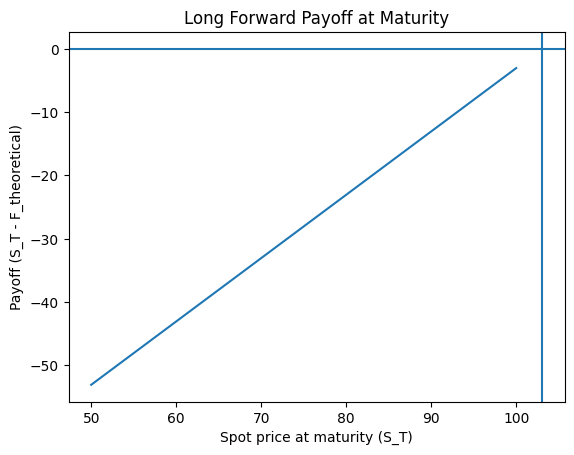


Multiple Cases Summary Table
      S0     r     y    T  F_market    F_theory  mispricing
0  100.0  0.05  0.00  1.0     120.0  105.127110   14.872890
1  100.0  0.05  0.02  1.0     105.0  103.045453    1.954547
2  100.0  0.03  0.04  0.5      98.0   99.501248   -1.501248

Simulated E[ST]   : 103.030330
Theoretical E[ST] : 103.045453
Difference        : -0.015123


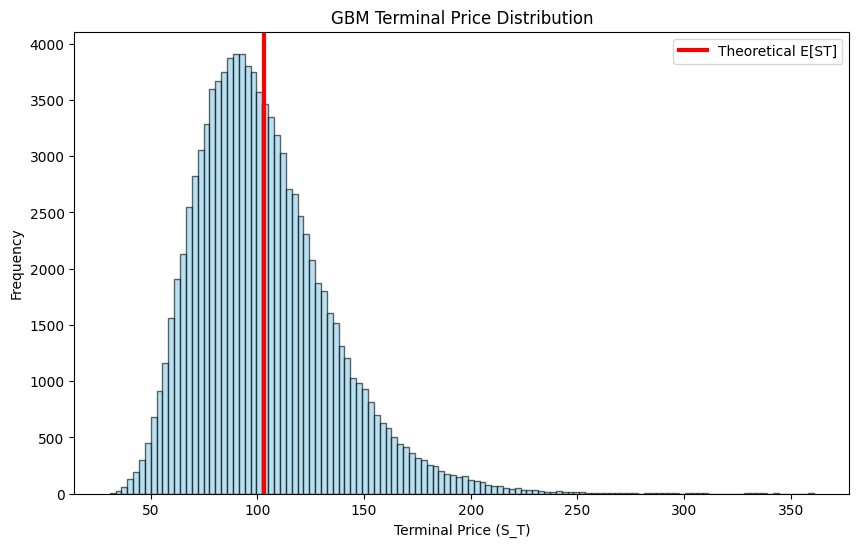


Black-Scholes Option Pricing
Call Price  : 13.0203
Put Price   : 10.1234
Delta Call  : 0.5869
Delta Put   : -0.3933
Gamma       : 0.0126
Vega        : 37.9012
Theta Call  : -6.7947
Theta Put   : -3.9990
Call-Put Parity Test,
LHS = C - P                    : 2.8969
RHS = S0*exp(-yT) - K*exp(-rT) : 2.8969
Difference                     : 0.0000

Monte Carlo (European) Option Pricing
Simulations                    : 100000

Call price                     : 13.0247
Std Error                      : 0.0683
Antithetic Variates            : 0.0541
95% CI                         :[12.8908,13.1586]

Put price                      : 10.1238
Std Error (Standard MC)        : 0.0425
Std Error (Antithetic MC)      : 0.0278
95% CI                         :[10.0405,10.2072]
Call-Put Parity Test,
LHS = C - P                    : 2.9008
RHS = S0*exp(-yT) - K*exp(-rT) : 2.8969
Difference                     : 0.0039

Monte Carlo (Asian) Option Pricing
Simulations                    : 100000

Call price  

In [96]:
#Main Code
if __name__ == "__main__":
    #Inputs
    S0 = 100.0 #Intial spot price
    r = 0.05 #Risk free rate per year
    y = 0.02 #Dividend per year
    F_market = 120 #Market forward price
    sigma = 0.30 #Volatility
    T = 1.0 #Maturity time
    N = 100000 #Number of case
    M = 12 # Number of time steps in each simulated price path
    K = 100.0 #Strike Price
    cases = [
        dict(S0=100.0, r=0.05, y=0.00, T=1.0, F_market=120.0),
        dict(S0=100.0, r=0.05, y=0.02, T=1.0, F_market=105.0),
        dict(S0=100.0, r=0.03, y=0.04, T=0.5, F_market=98.0),
    ] #For multiple cases

    #Initial points
    total_payoff_call = 0 #Total payoff starting point (Call)
    total_payoff_put = 0 # Total payoff starting point (Put)
    ST_sum = 0

    #MAIN functions
    run_single_case(S0, r, y, T, F_market)
    run_multiple_cases(cases)
    comparison_gbm(S0, r, y, sigma, T, N)
    greeks = black_scholes_greeks(S0,K,r,y,sigma,T)
    black_scholes_option_price (S0, K, r, y, sigma, T, greeks)
    european_option_price (S0, r, y, T, sigma, N, total_payoff_call, total_payoff_put, K)
    asian_option_price (S0, r, y, T, sigma, N, M, total_payoff_call, total_payoff_put, ST_sum, K)